In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import scipy.stats as stats 
import matplotlib.pyplot as plt 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score 

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from sklearn.preprocessing import PowerTransformer

In [30]:
df = pd.read_csv('concrete_data.csv')

In [31]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [32]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [33]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [34]:
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:8],df['Strength'],test_size=0.25,random_state=40)

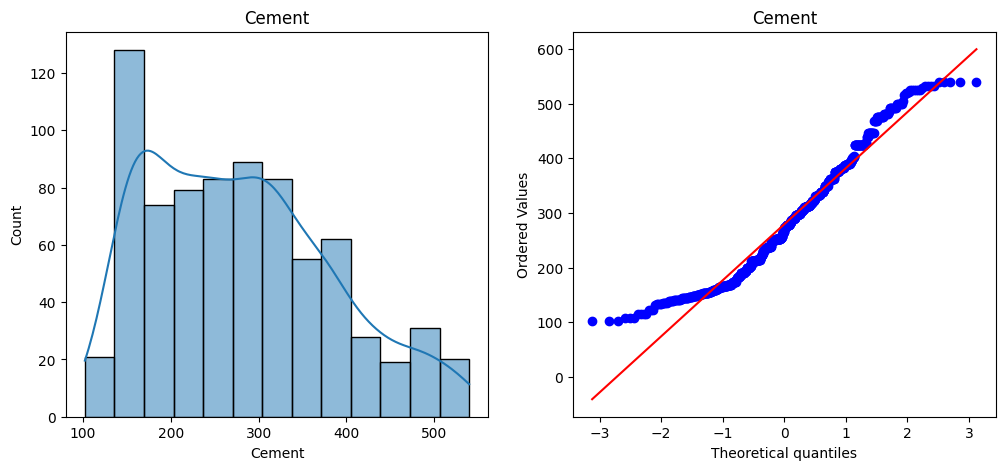

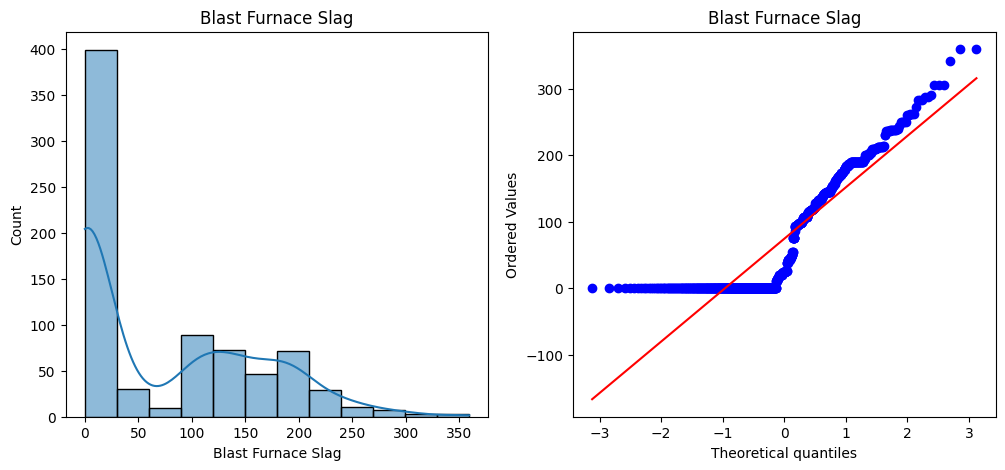

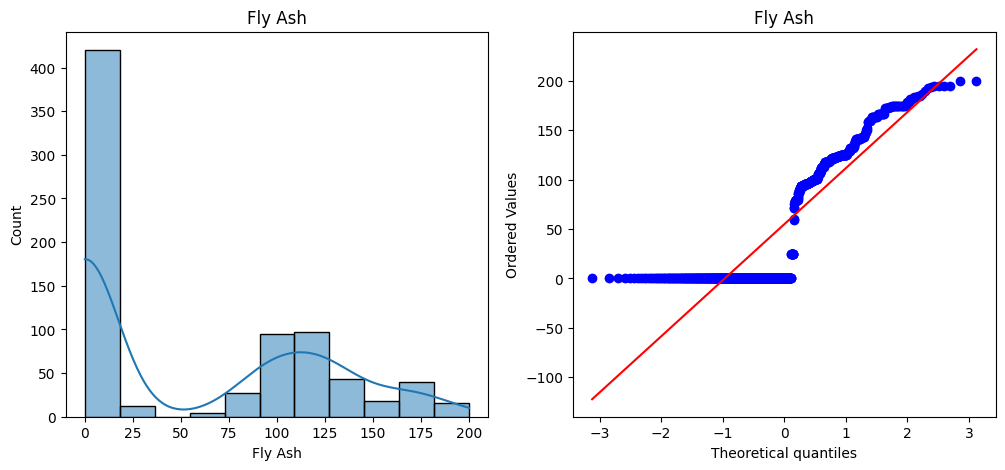

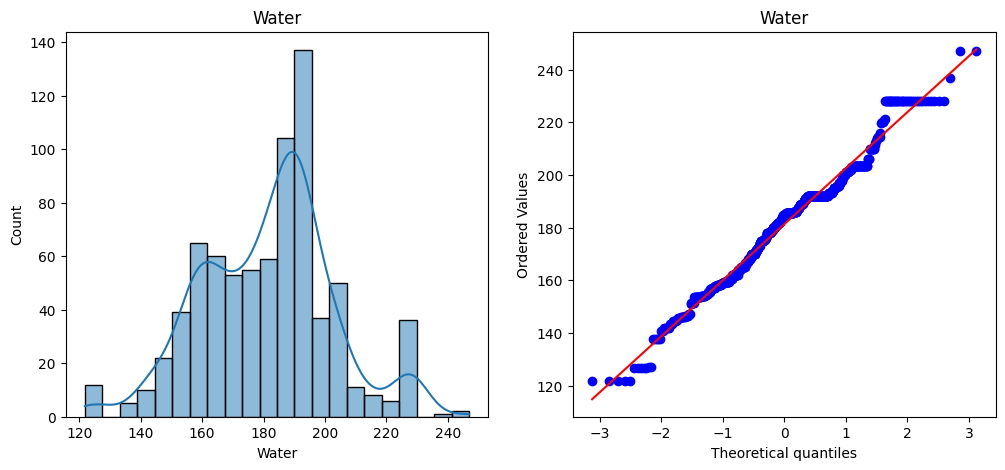

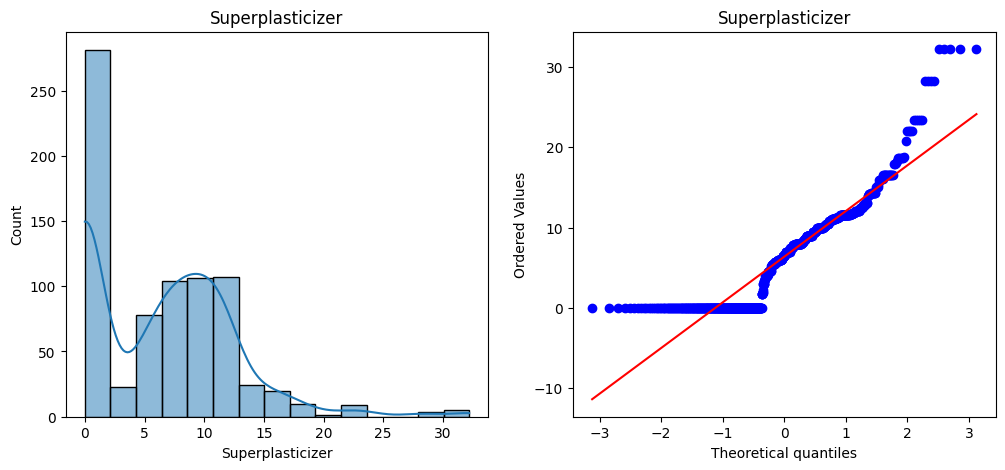

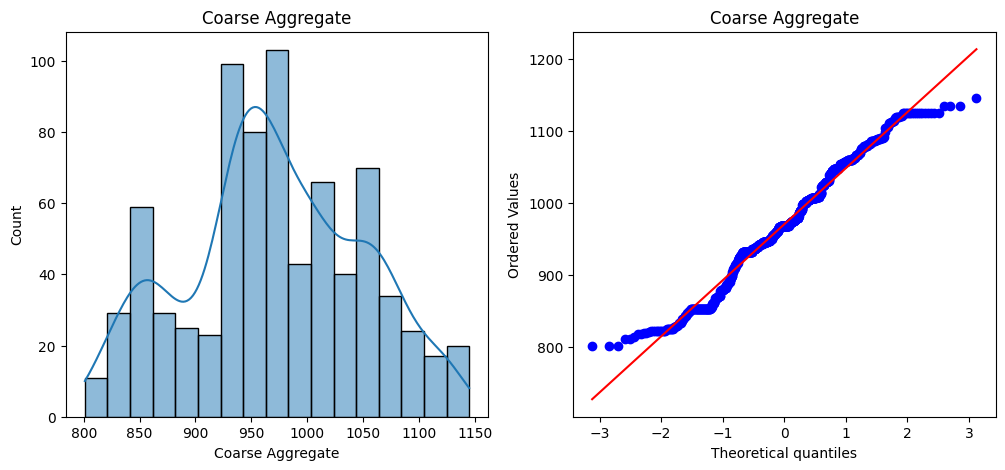

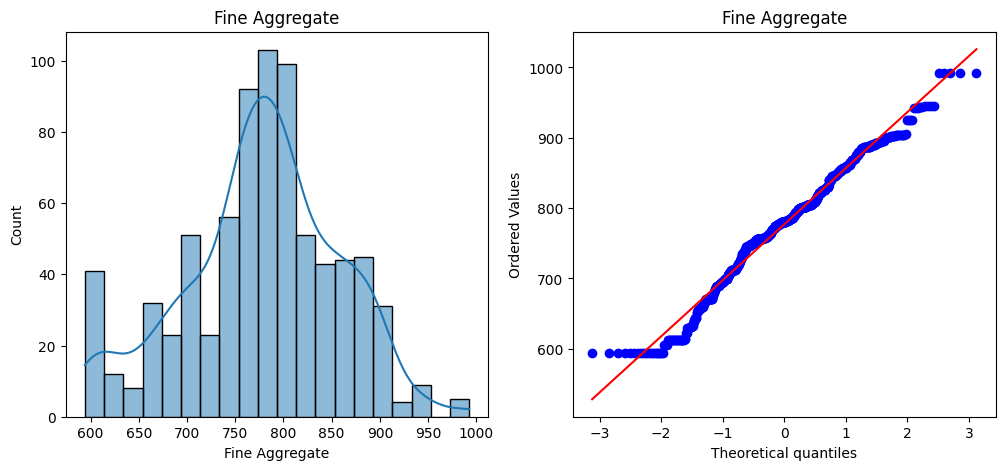

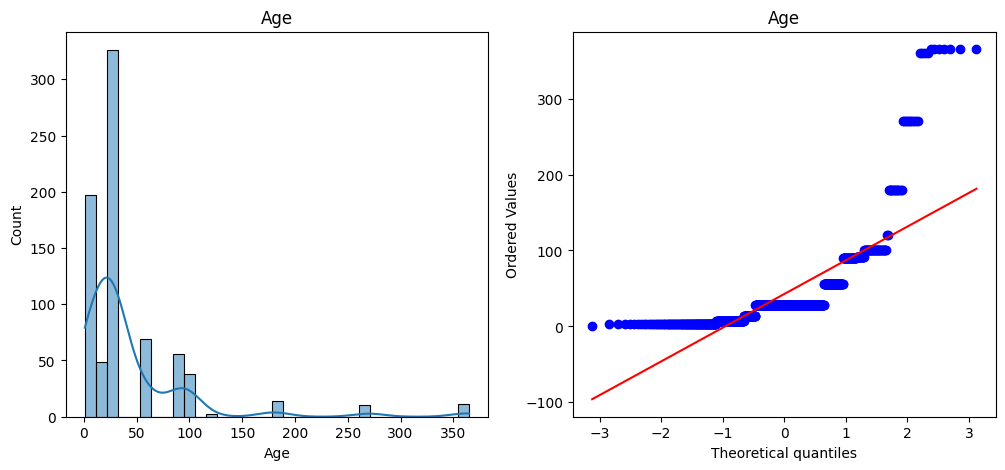

In [35]:
# ploting graphs for all columns
for i in x_train.columns:
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    sns.histplot(x_train[i],kde=True)
    plt.title(i)

    plt.subplot(122)
    stats.probplot(x_train[i],plot=plt)
    plt.title(i)

    plt.show()

In [36]:
# we can easily visualize that some collumns are okay but some are very much skewed 
# applying box cox transform then making model and testing it 

power = PowerTransformer(method='box-cox')

In [80]:
# applying box cox 
x_train_box_cox = power.fit_transform(x_train+0.000001)
x_test_box_cox = power.transform(x_test+0.000001)

In [81]:
# we can see lamdas for all columns 
power.lambdas_

array([ 0.15294343,  0.03556796, -0.12390117,  0.97909869,  0.283326  ,
        1.01961957,  1.79258214,  0.01391941])

In [82]:
# now making two models before and after transformation to see results 
# note that this do scaling also 
clf1 = LinearRegression()

In [83]:
clf1.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
pred1 = clf1.predict(x_test)

In [85]:
r2_score(y_test,pred1)

0.5007852983475878

In [86]:
# we can see only 50% is coming now for our transformed data 
clf2 = LinearRegression()
clf2.fit(x_train_box_cox,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [87]:
pred2 = clf2.predict(x_test_box_cox)

In [88]:
r2_score(y_test,pred2)

0.7548029119537465

In [70]:
# we can see we significantly improved our model 
# now we can plot before and after qq plots to see that how well they are 
x_train_box_cox = pd.DataFrame(x_train_box_cox,columns=x_train.columns)

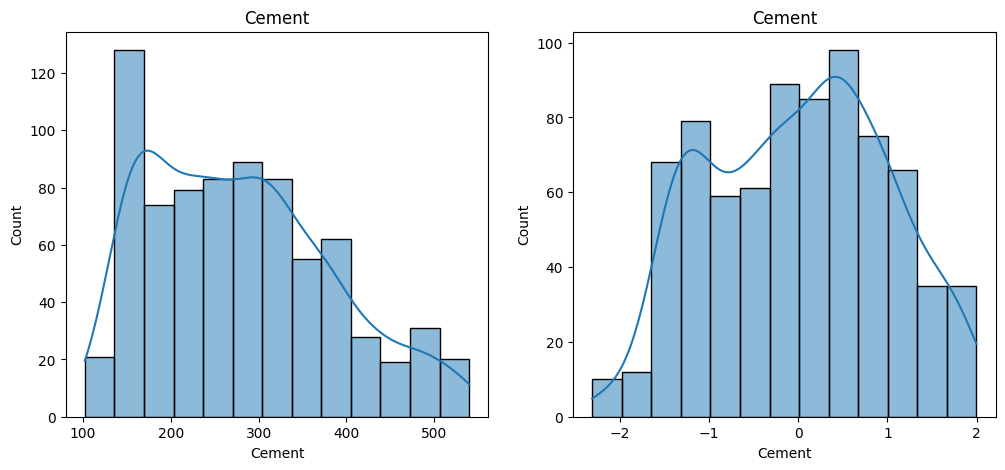

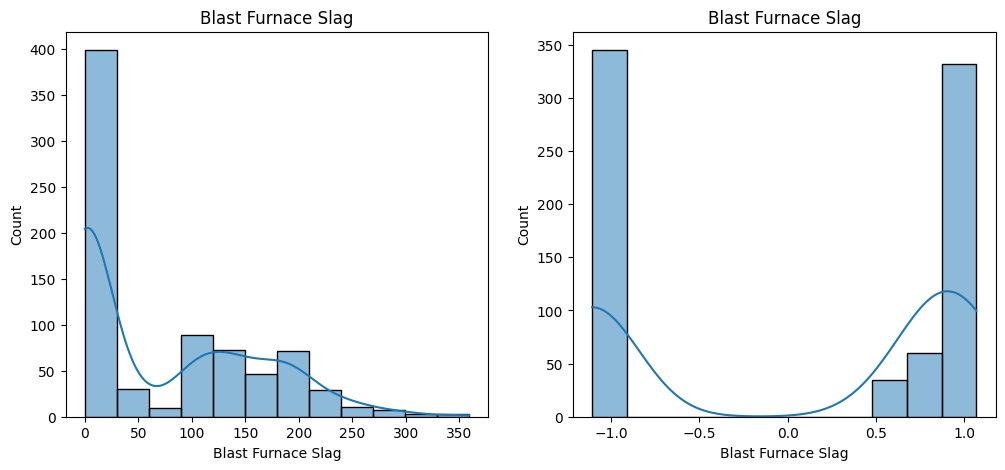

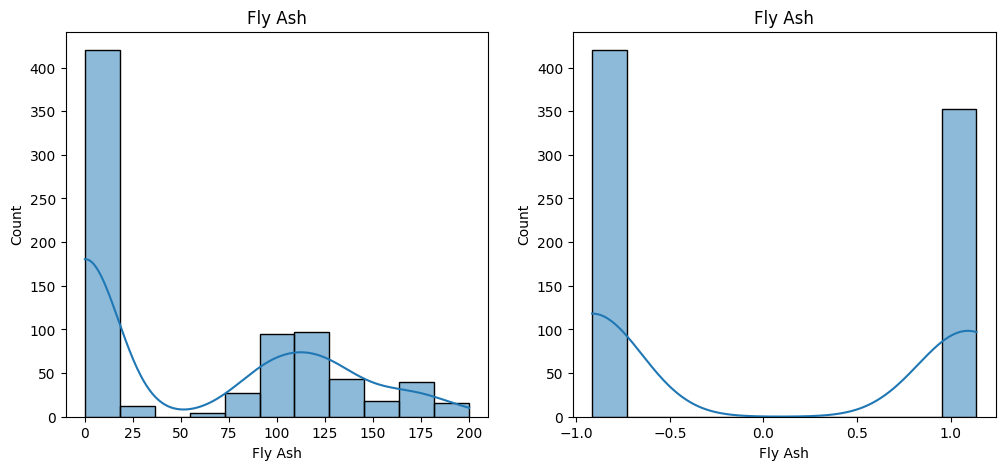

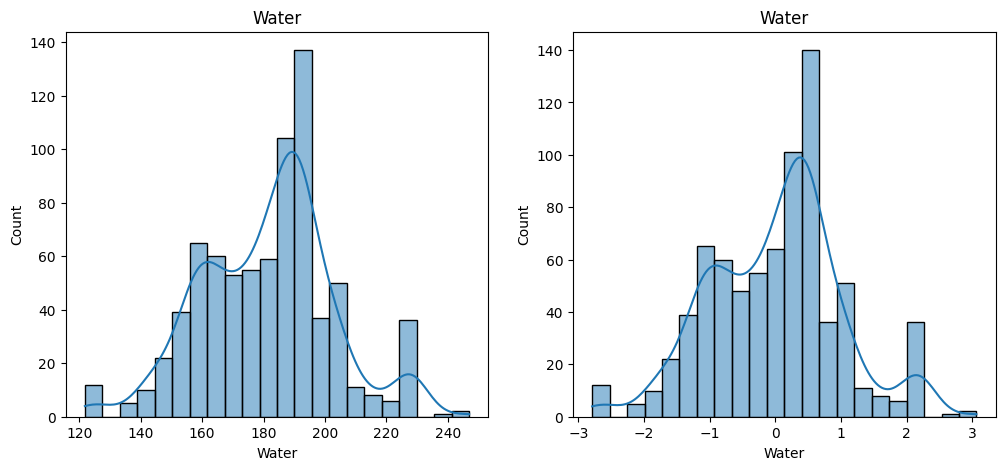

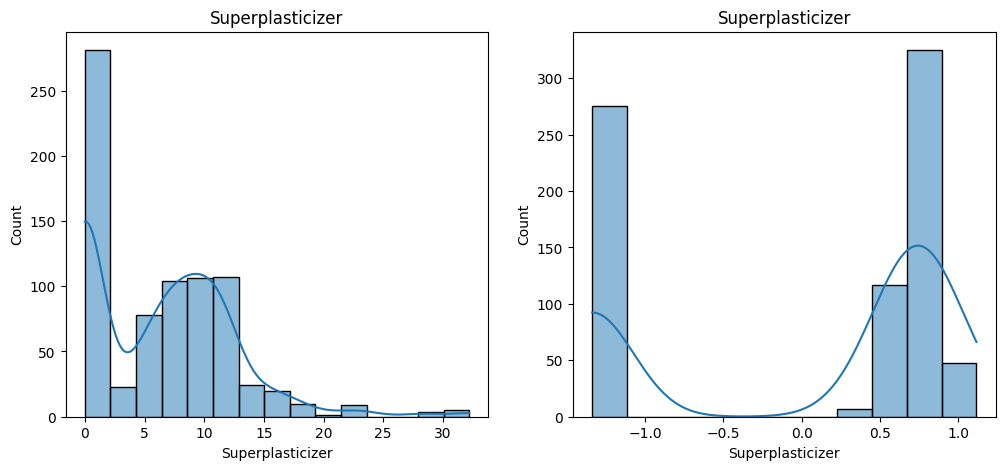

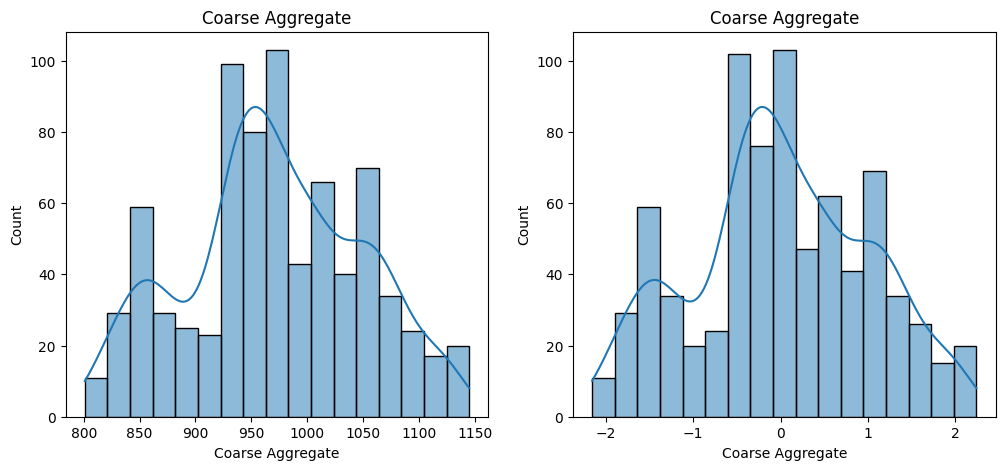

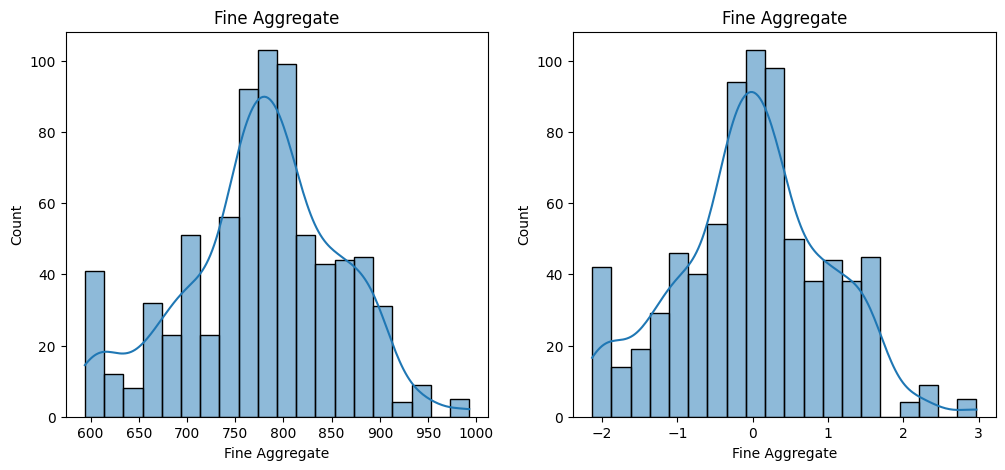

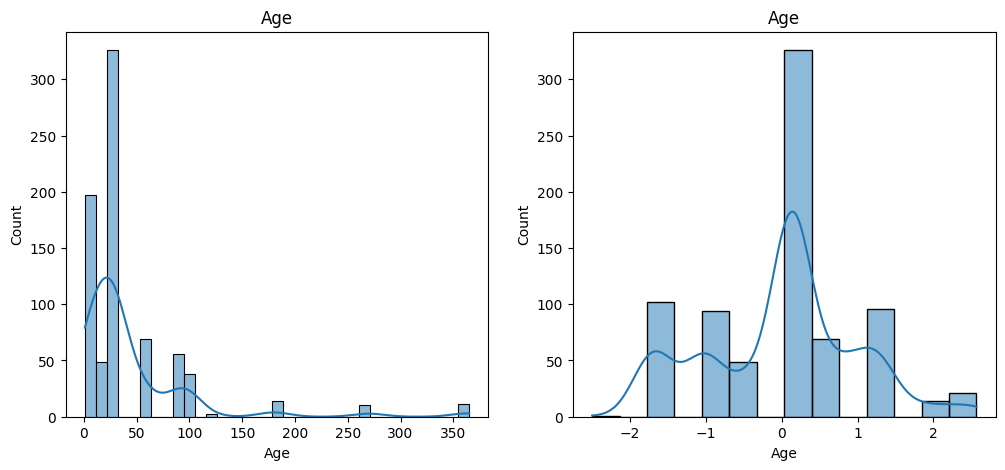

In [72]:
# ploting graphs for all columns
for i in x_train.columns:
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    sns.histplot(x_train[i],kde=True)
    plt.title(i)

    plt.subplot(122)
    sns.histplot(x_train_box_cox[i],kde=True)
    plt.title(i)

    plt.show()

In [73]:
# we can see that some we made them more normal than before 

In [74]:
# applying the yeo jhonson method
power = PowerTransformer()
x_train_yeo = power.fit_transform(x_train)

In [75]:
x_test_yeo = power.transform(x_test)

In [89]:
# cheking r2 score with linear regeression 
clf3 = LinearRegression()
clf3.fit(x_train_yeo,y_train)
pred3 = clf2.predict(x_test_yeo)
r2_score(y_test,pred3)

0.7548029194078383

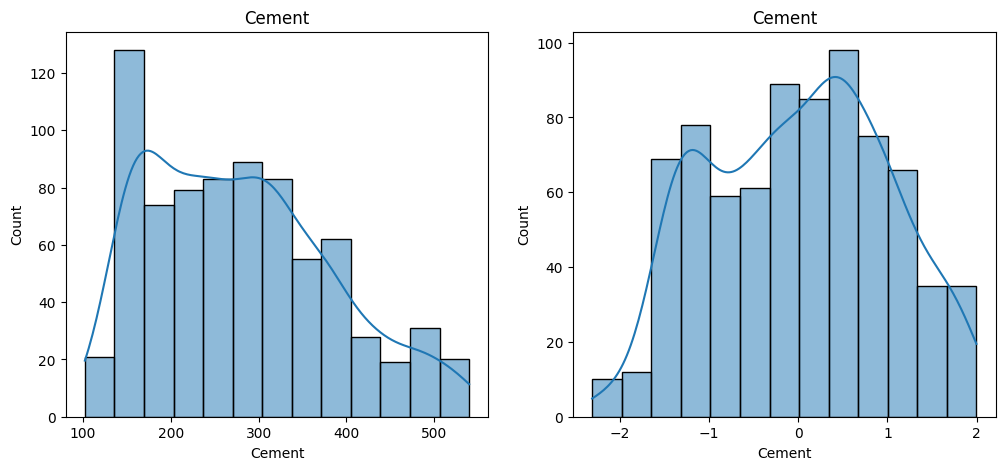

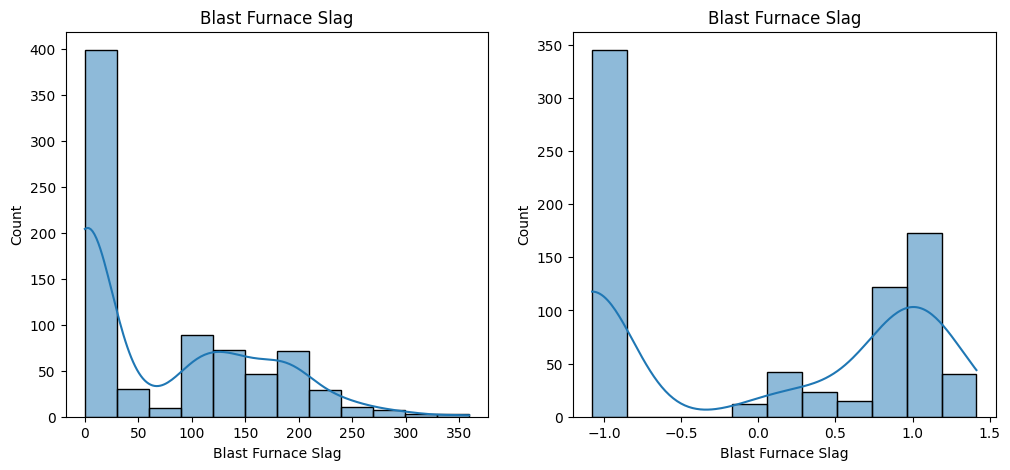

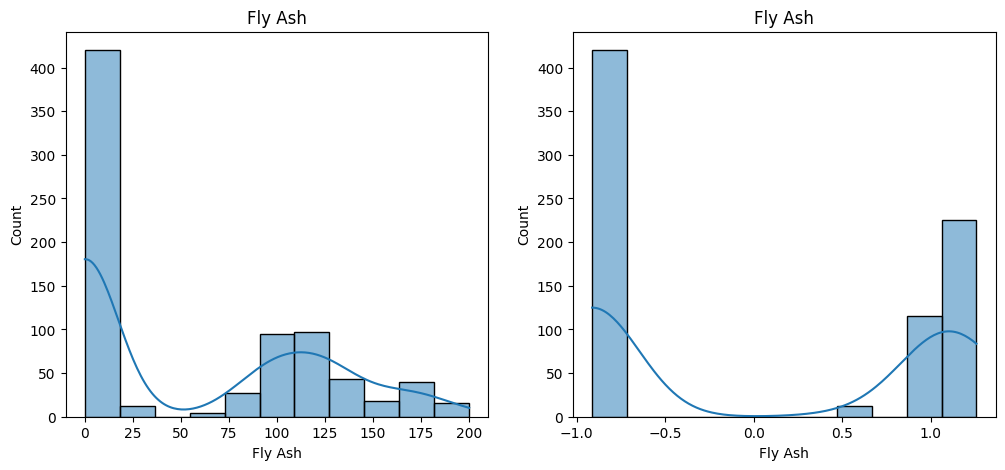

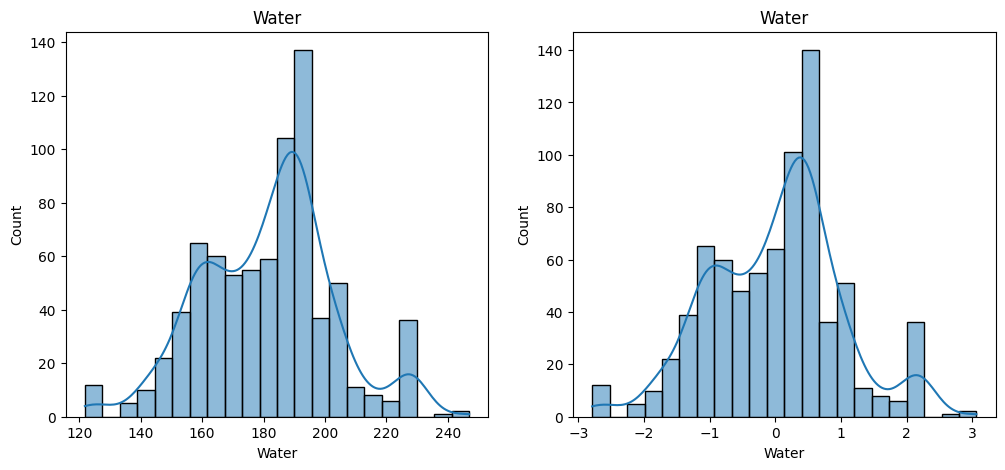

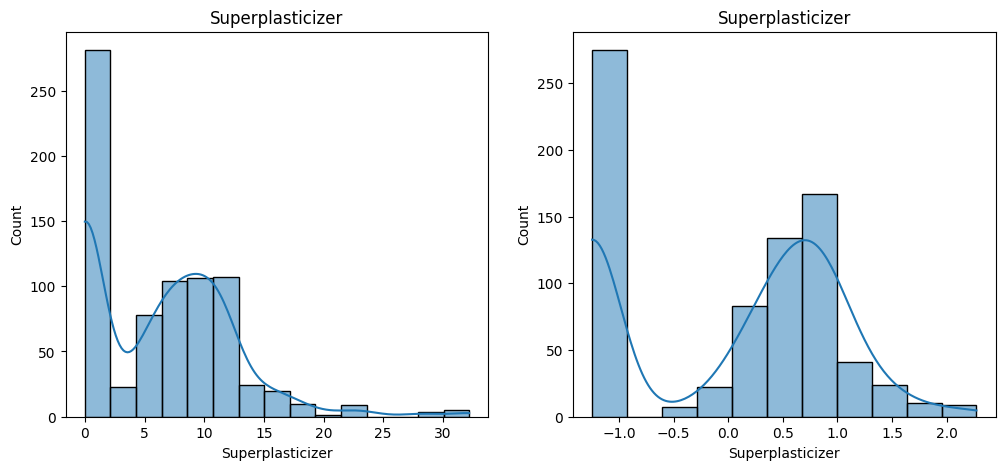

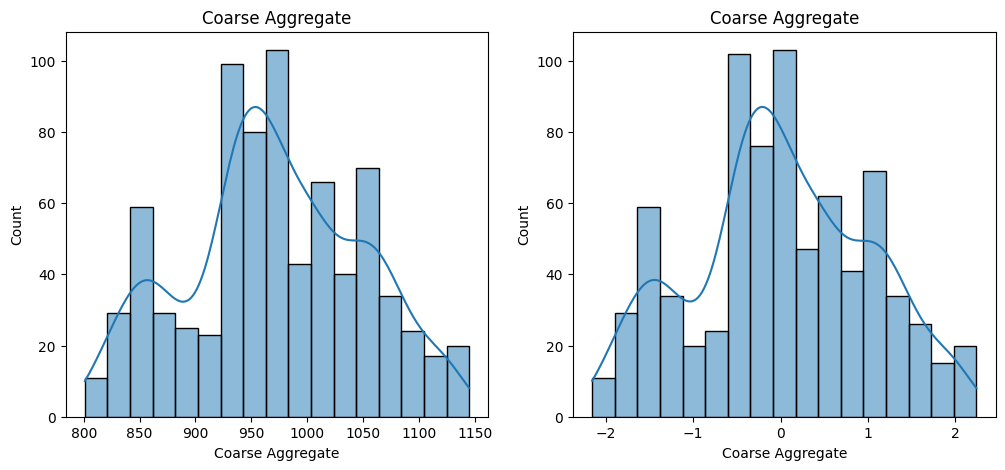

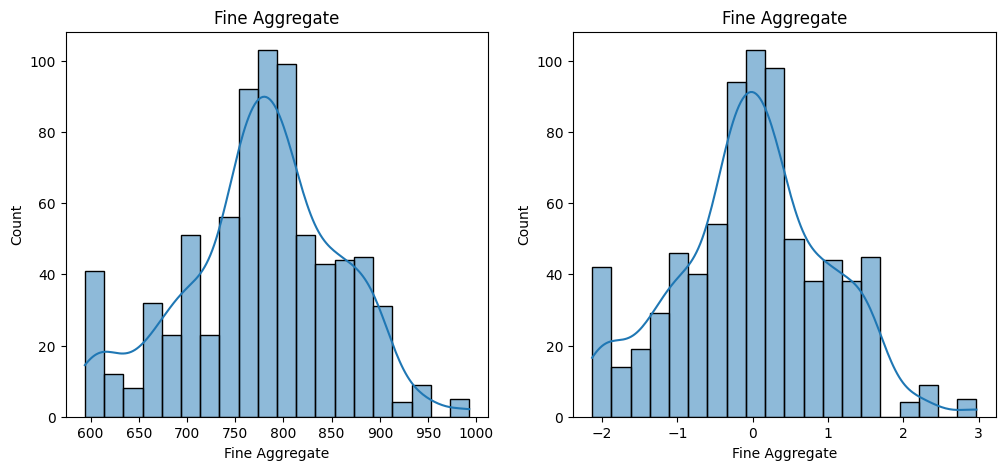

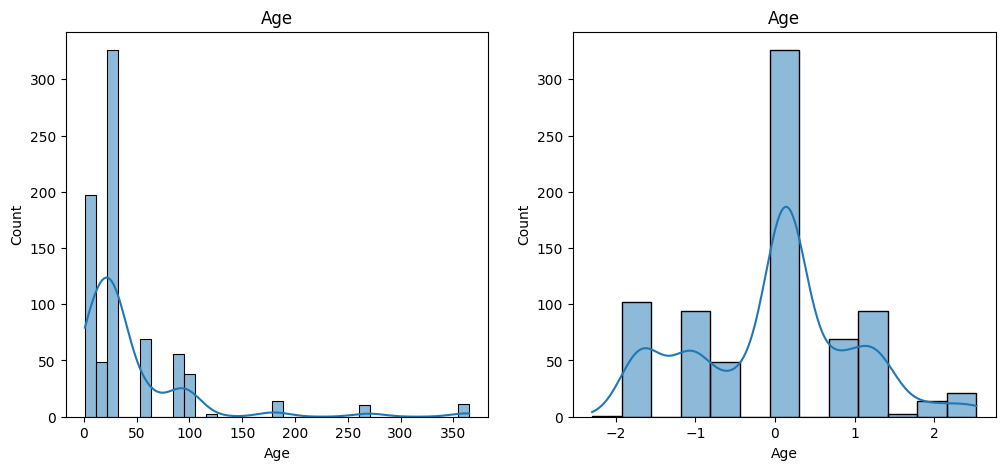

In [90]:
# ploting graph to see how it did 
# ploting graphs for all columns

x_train_yeo = pd.DataFrame(x_train_yeo,columns=x_train.columns)

for i in x_train.columns:
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    sns.histplot(x_train[i],kde=True)
    plt.title(i)

    plt.subplot(122)
    sns.histplot(x_train_yeo[i],kde=True)
    plt.title(i)

    plt.show()

In [ ]:
# we applied both transformations 